# 02 — Colab: Fine-tune EfficientNet-B0 on Egyptian frames

**Run after Kaggle notebook 01 finishes.**

You need:
1. Egyptian frames + `manifest.csv` (from your extract notebook), e.g. `MyDrive/MasterData/egypt_modalink_frames/`
2. Uploaded / Drive copy of **`best_model_efficientnet_b0.h5`** from Kaggle (full model, not weights-only)

**Rules:**
- Use `load_model(...)` only — do **not** rebuild EfficientNet and `load_weights`
- Abort if EfficientNet check fails
- Output: `best_model_efficientnet_egypt_ft.h5` (+ metrics)

**Class weights:** optional sklearn `balanced` only (no happy/sad special boost). Toggle `USE_BALANCED_CLASS_WEIGHT`.


In [1]:
# 1) Mount Drive
from google.colab import drive
drive.mount("/content/drive", force_remount=True)

from pathlib import Path
print("MyDrive top folders:")
for p in sorted(Path("/content/drive/MyDrive").iterdir())[:40]:
    print(" -", p.name)


Mounted at /content/drive
MyDrive top folders:
 - Colab Notebooks
 - Final Modalink Dataset
 - MasterData
 - egypt_modalink_frames


In [3]:
# 2) CONFIG
from pathlib import Path

MYDRIVE = Path("/content/drive/MyDrive")

CANDIDATES = [
    MYDRIVE / "MasterData" / "egypt_modalink_frames_v3"

]
FRAMES_ROOT = next((p for p in CANDIDATES if p.exists()), CANDIDATES[0])

# Baseline from Kaggle — upload to /content or point to Drive
BASELINE_H5 = Path("/content/best_model_efficientnet_b0.h5")
# BASELINE_H5 = MYDRIVE / "MasterData" / "models" / "best_model_efficientnet_b0.h5"

OUT_DIR = MYDRIVE / "MasterData" / "models"
OUT_DIR.mkdir(parents=True, exist_ok=True)

IMAGE_SIZE = 96  # must match Kaggle baseline
BATCH_SIZE = 32
SEED = 42
TRAIN_RATIO, VAL_RATIO = 0.70, 0.15

STAGE1_EPOCHS = 12
STAGE2_EPOCHS = 20
UNFREEZE_LAST_N = 40

# Optional: use sklearn balanced class_weight only (no happy/sad special boost)
USE_BALANCED_CLASS_WEIGHT = True

print("FRAMES_ROOT exists:", FRAMES_ROOT.exists(), "→", FRAMES_ROOT)
print("BASELINE_H5 exists:", BASELINE_H5.exists(), "→", BASELINE_H5)
print("OUT_DIR:", OUT_DIR)
assert FRAMES_ROOT.exists(), f"Frames folder not found. Checked: {CANDIDATES}"
assert (FRAMES_ROOT / "manifest.csv").exists(), f"Missing manifest.csv under {FRAMES_ROOT}"
assert BASELINE_H5.exists(), (
    "Upload best_model_efficientnet_b0.h5 to /content/ or set BASELINE_H5 to your Drive path"
)


FRAMES_ROOT exists: True → /content/drive/MyDrive/MasterData/egypt_modalink_frames_v3
BASELINE_H5 exists: True → /content/best_model_efficientnet_b0.h5
OUT_DIR: /content/drive/MyDrive/MasterData/models


In [4]:
# 3) Install / imports
!pip -q install scikit-learn pandas opencv-python-headless seaborn

import json
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import seaborn as sns

tf.keras.utils.set_random_seed(SEED)
print("TF:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))


TF: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [5]:
# 4) Load manifest + person-level split
manifest = pd.read_csv(FRAMES_ROOT / "manifest.csv")
print("manifest rows:", len(manifest))
print("columns:", list(manifest.columns))
print(manifest.head(3))

def pick_col(df, options):
    for c in options:
        if c in df.columns:
            return c
    raise KeyError(f"None of {options} in columns={list(df.columns)}")

EMOTION_COL = pick_col(manifest, ["emotion", "label", "class"])
PATH_COL = pick_col(manifest, ["image_path", "rel_path", "frame_path", "path", "filepath"])
PERSON_COL = pick_col(manifest, ["person_id", "person_key", "person"])

df = manifest.copy()
df["emotion"] = df[EMOTION_COL].astype(str).str.strip().str.lower()
df = df[~df["emotion"].isin(["nan", "none", "", "ambiguous", "unknown"])].copy()

CANON = ["angry", "disgust", "fear", "happy", "neutral", "sad", "surprise"]
ALIAS = {
    "anger": "angry", "angry": "angry",
    "disgust": "disgust",
    "fear": "fear",
    "happiness": "happy", "happy": "happy",
    "neutral": "neutral",
    "sadness": "sad", "sad": "sad",
    "surprise": "surprise",
}
df["emotion"] = df["emotion"].map(lambda x: ALIAS.get(x, x))
df = df[df["emotion"].isin(CANON)].copy()

def resolve_path(p):
    p = Path(str(p))
    if p.is_absolute() and p.exists():
        return p
    cand = FRAMES_ROOT / p
    if cand.exists():
        return cand
    cand2 = MYDRIVE / p
    if cand2.exists():
        return cand2
    return cand

df["abs_path"] = df[PATH_COL].map(resolve_path)
df = df[df["abs_path"].map(lambda p: Path(p).exists())].copy()
print("usable frames:", len(df))
print("class counts:\n", df["emotion"].value_counts())
print("unique persons:", df[PERSON_COL].nunique())

meta_path = BASELINE_H5.with_name("metrics.json")
if not meta_path.exists():
    meta_path = BASELINE_H5.parent / "metrics.json"
if meta_path.exists():
    meta = json.loads(meta_path.read_text())
    CLASS_NAMES = list(meta.get("class_names", CANON))
    print("CLASS_NAMES from metrics.json:", CLASS_NAMES)
else:
    CLASS_NAMES = CANON
    print("CLASS_NAMES (default FER order):", CLASS_NAMES)

df = df[df["emotion"].isin(CLASS_NAMES)].copy()
label_to_idx = {c: i for i, c in enumerate(CLASS_NAMES)}
df["y"] = df["emotion"].map(label_to_idx)

persons = df[PERSON_COL].unique()
train_p, temp_p = train_test_split(persons, train_size=TRAIN_RATIO, random_state=SEED)
val_frac = VAL_RATIO / (1 - TRAIN_RATIO)
val_p, test_p = train_test_split(temp_p, train_size=val_frac, random_state=SEED)

split_map = {**{p: "train" for p in train_p}, **{p: "val" for p in val_p}, **{p: "test" for p in test_p}}
df["split"] = df[PERSON_COL].map(split_map)

for s in ["train", "val", "test"]:
    sub = df[df["split"] == s]
    print(f"{s}: frames={len(sub)} persons={sub[PERSON_COL].nunique()} classes={sub['emotion'].value_counts().to_dict()}")

assert set(df.loc[df.split == "train", PERSON_COL]).isdisjoint(df.loc[df.split == "test", PERSON_COL])
print("Person leakage check: OK")


manifest rows: 2135
columns: ['image_path', 'emotion', 'person_id', 'folder', 'speaker', 'video_path', 'excel_row']
                                          image_path  emotion  \
0  /content/drive/MyDrive/MasterData/egypt_modali...  disgust   
1  /content/drive/MyDrive/MasterData/egypt_modali...  disgust   
2  /content/drive/MyDrive/MasterData/egypt_modali...  disgust   

                        person_id               folder     speaker  \
0  videoplayback (141)|SPEAKER_01  videoplayback (141)  SPEAKER_01   
1  videoplayback (141)|SPEAKER_01  videoplayback (141)  SPEAKER_01   
2  videoplayback (141)|SPEAKER_01  videoplayback (141)  SPEAKER_01   

                                          video_path  excel_row  
0  /content/drive/MyDrive/Final Modalink Dataset/...        342  
1  /content/drive/MyDrive/Final Modalink Dataset/...        342  
2  /content/drive/MyDrive/Final Modalink Dataset/...        342  
usable frames: 2135
class counts:
 emotion
angry       586
sad         490
sur

In [14]:
# 5) tf.data + weights from TEST matrix + stronger augmentation
AUTOTUNE = tf.data.AUTOTUNE

def load_image(path, y):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMAGE_SIZE, IMAGE_SIZE])
    img = tf.cast(img, tf.float32)
    img = tf.keras.applications.efficientnet.preprocess_input(img)
    return img, y

def make_ds(split, shuffle=False, augment=False):
    sub = df[df["split"] == split]
    paths = sub["abs_path"].astype(str).tolist()
    ys = sub["y"].astype(np.int32).tolist()
    ds = tf.data.Dataset.from_tensor_slices((paths, ys))
    ds = ds.map(load_image, num_parallel_calls=AUTOTUNE)
    if augment:
        def aug(x, y):
            x = tf.image.random_flip_left_right(x)
            x = tf.image.random_brightness(x, 0.15)
            x = tf.image.random_contrast(x, 0.85, 1.15)
            x = tf.image.random_saturation(x, 0.85, 1.15)
            # small translation via pad+crop
            x = tf.image.resize_with_crop_or_pad(x, IMAGE_SIZE + 8, IMAGE_SIZE + 8)
            x = tf.image.random_crop(x, size=[IMAGE_SIZE, IMAGE_SIZE, 3])
            return x, y
        ds = ds.map(aug, num_parallel_calls=AUTOTUNE)
    if shuffle:
        ds = ds.shuffle(min(len(paths), 2048), seed=SEED, reshuffle_each_iteration=True)
    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

train_ds = make_ds("train", shuffle=True, augment=True)
val_ds = make_ds("val")
test_ds = make_ds("test")

y_train = df.loc[df["split"] == "train", "y"].values
counts = Counter(y_train.tolist())
print("Train class counts:")
for i, name in enumerate(CLASS_NAMES):
    print(f"  {name:10s}: {counts.get(i, 0)}")

base = compute_class_weight(
    "balanced", classes=np.arange(len(CLASS_NAMES)), y=y_train
)
balanced = {int(i): float(w) for i, w in enumerate(base)}

# From heatmap/report: neutral=0 recall, happy weak, fear/disgust over-predicted
EXTRA_MULT = {
    "angry": 0.65,
    "disgust": 0.85,
    "fear": 0.90,
    "happy": 1.70,
    "neutral": 2.20,
    "sad": 1.25,
    "surprise": 1.35,
}
MAX_WEIGHT, MIN_WEIGHT = 6.0, 0.30

CLASS_WEIGHT = {}
for i, name in enumerate(CLASS_NAMES):
    w = balanced[i] * EXTRA_MULT.get(name, 1.0)
    CLASS_WEIGHT[i] = float(np.clip(w, MIN_WEIGHT, MAX_WEIGHT))

print("\nBalanced → suggested (from TEST matrix):")
for i, name in enumerate(CLASS_NAMES):
    print(
        f"  {name:10s}: {balanced[i]:.3f} × {EXTRA_MULT[name]:.2f} "
        f"→ {CLASS_WEIGHT[i]:.3f} (n={counts.get(i, 0)})"
    )

USE_BALANCED_CLASS_WEIGHT = True
print("\nUsing CLASS_WEIGHT:", CLASS_WEIGHT)
print("Next: cells 7 → 8 → 9 → 10. Prefer FRAMES_ROOT = egypt_modalink_frames_v3 if ready.")

Train class counts:
  angry     : 429
  disgust   : 119
  fear      : 91
  happy     : 186
  neutral   : 131
  sad       : 343
  surprise  : 160

Balanced → suggested (from TEST matrix):
  angry     : 0.486 × 0.65 → 0.316 (n=429)
  disgust   : 1.752 × 0.85 → 1.489 (n=119)
  fear      : 2.290 × 0.90 → 2.061 (n=91)
  happy     : 1.121 × 1.70 → 1.905 (n=186)
  neutral   : 1.591 × 2.20 → 3.500 (n=131)
  sad       : 0.608 × 1.25 → 0.760 (n=343)
  surprise  : 1.303 × 1.35 → 1.759 (n=160)

Using CLASS_WEIGHT: {0: 0.3158008658008658, 1: 1.4887755102040816, 2: 2.06138147566719, 3: 1.9049923195084486, 4: 3.500327153762268, 5: 0.759579341940858, 6: 1.7586160714285715}
Next: cells 7 → 8 → 9 → 10. Prefer FRAMES_ROOT = egypt_modalink_frames_v3 if ready.


In [15]:
# 6) Load FULL baseline (do NOT rebuild + load_weights)
print("Loading:", BASELINE_H5)
try:
    model = tf.keras.models.load_model(str(BASELINE_H5), compile=False)
except Exception as e:
    raise RuntimeError(
        "Could not load full model from .h5. "
        "Re-download best_model_efficientnet_b0.h5 from Kaggle Output "
        f"(full model save). Original error: {e}"
    ) from e

def has_efficientnet(m):
    if "efficientnet" in m.name.lower():
        return True
    for l in m.layers:
        if "efficientnet" in l.name.lower():
            return True
        if hasattr(l, "layers") and any("efficientnet" in x.name.lower() for x in l.layers):
            return True
    return False

print("Loaded model name:", model.name)
print("Top-level layers:", [l.name for l in model.layers])
assert has_efficientnet(model), (
    "Loaded file is NOT EfficientNet. Use best_model_efficientnet_b0.h5 from notebook 01."
)
print("EfficientNet check: OK")
model.summary()

eff_base = None
for layer in model.layers:
    if "efficientnet" in layer.name.lower() and hasattr(layer, "layers"):
        eff_base = layer
        break
print(
    "EfficientNet base layer:",
    None if eff_base is None else f"{eff_base.name} ({len(eff_base.layers)} inner layers)",
)
if eff_base is None:
    print("WARNING: nested EfficientNet base not found — Stage 2 will unfreeze top layers only")


Loading: /content/best_model_efficientnet_b0.h5
Loaded model name: efficientnet_b0_emotion
Top-level layers: ['image', 'efficientnetb0', 'gap', 'drop1', 'fc', 'bn', 'drop2', 'probs']
EfficientNet check: OK


Model: "efficientnet_b0_emotion"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image (InputLayer)              │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 3, 3, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop1 (Dropout)                 │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc (Dense)                      │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn (BatchNormalization)         │ (None, 256)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop2 (Dropout)                 │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ probs (Dense)                   │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,380,330 (16.71 MB)

 Trainable params: 1,826,407 (6.97 MB)

 Non-trainable params: 2,553,923 (9.74 MB)

EfficientNet base layer: efficientnetb0 (238 inner layers)


In [23]:
import json
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import seaborn as sns

tf.keras.utils.set_random_seed(SEED)
print("TF:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))
# 7) Stage 1 — freeze backbone, train head
if eff_base is not None:
    eff_base.trainable = False
else:
    for layer in model.layers[:-4]:
        layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

ckpt1 = str(OUT_DIR / "ckpt_egypt_stage1.keras")
cbs1 = [
    tf.keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=4, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6),
    tf.keras.callbacks.ModelCheckpoint(ckpt1, monitor="val_accuracy", save_best_only=True, mode='min'),
]

print("Stage 1: head only")
hist1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=STAGE1_EPOCHS,
    class_weight=CLASS_WEIGHT if CLASS_WEIGHT else None,
    callbacks=cbs1,
)

TF: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Stage 1: head only
Epoch 1/12
46/46 ━━━━━━━━━━━━━━━━━━━━ 48s 525ms/step - accuracy: 0.4736 - loss: 1.3399 - val_accuracy: 0.2485 - val_loss: 2.3185 - learning_rate: 0.0010
Epoch 2/12
46/46 ━━━━━━━━━━━━━━━━━━━━ 4s 49ms/step - accuracy: 0.5161 - loss: 1.2191 - val_accuracy: 0.2607 - val_loss: 2.4009 - learning_rate: 0.0010
Epoch 3/12
46/46 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - accuracy: 0.5517 - loss: 1.0817 - val_accuracy: 0.2454 - val_loss: 2.3995 - learning_rate: 0.0010
Epoch 4/12
46/46 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - accuracy: 0.5757 - loss: 0.9905 - val_accuracy: 0.2393 - val_loss: 2.4019 - learning_rate: 5.0000e-04
Epoch 5/12
46/46 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - accuracy: 0.5874 - loss: 0.9936 - val_accuracy: 0.2362 - val_loss: 2.4493 - learning_rate: 5.0000e-04
Epoch 6/12
46/46 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.6086 - loss: 0.9536 - val_accuracy: 0.2485 - val_loss: 2.4610 - lear

In [24]:
# 8) Stage 2 — unfreeze last N EfficientNet layers
if eff_base is not None:
    eff_base.trainable = True
    n = len(eff_base.layers)
    freeze_until = max(0, n - UNFREEZE_LAST_N)
    for i, layer in enumerate(eff_base.layers):
        layer.trainable = i >= freeze_until
    print(f"Unfroze last {UNFREEZE_LAST_N} of {n} EfficientNet layers")
else:
    for layer in model.layers:
        layer.trainable = True

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

ckpt2 = str(OUT_DIR / "best_model_efficientnet_egypt_ft.keras")
cbs2 = [
    tf.keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-7),
    tf.keras.callbacks.ModelCheckpoint(ckpt2, monitor="val_accuracy", save_best_only=True),
]

print("Stage 2: fine-tune")
hist2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=STAGE2_EPOCHS,
    class_weight=CLASS_WEIGHT if CLASS_WEIGHT else None,
    callbacks=cbs2,
)


Unfroze last 40 of 238 EfficientNet layers
Stage 2: fine-tune
Epoch 1/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 73s 874ms/step - accuracy: 0.4393 - loss: 1.4603 - val_accuracy: 0.2546 - val_loss: 2.3936 - learning_rate: 1.0000e-05
Epoch 2/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.4524 - loss: 1.4187 - val_accuracy: 0.2515 - val_loss: 2.3877 - learning_rate: 1.0000e-05
Epoch 3/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.4428 - loss: 1.4671 - val_accuracy: 0.2423 - val_loss: 2.3908 - learning_rate: 1.0000e-05
Epoch 4/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 0.4469 - loss: 1.4625 - val_accuracy: 0.2393 - val_loss: 2.3923 - learning_rate: 1.0000e-05
Epoch 5/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.4839 - loss: 1.3501 - val_accuracy: 0.2239 - val_loss: 2.3969 - learning_rate: 5.0000e-06
Epoch 6/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - accuracy: 0.4681 - loss: 1.4021 - val_accuracy: 0.2270 - val_loss: 2.3985 - learning_rate: 5.0000e-06


TEST accuracy: 0.1743
TEST macro-F1: 0.1668
              precision    recall  f1-score   support

       angry       0.44      0.10      0.16        71
     disgust       0.06      0.06      0.06        31
        fear       0.17      0.20      0.18        20
       happy       0.14      0.25      0.18        51
     neutral       0.13      0.28      0.17        43
         sad       0.31      0.19      0.23        75
    surprise       0.20      0.15      0.17        59

    accuracy                           0.17       350
   macro avg       0.21      0.18      0.17       350
weighted avg       0.24      0.17      0.18       350



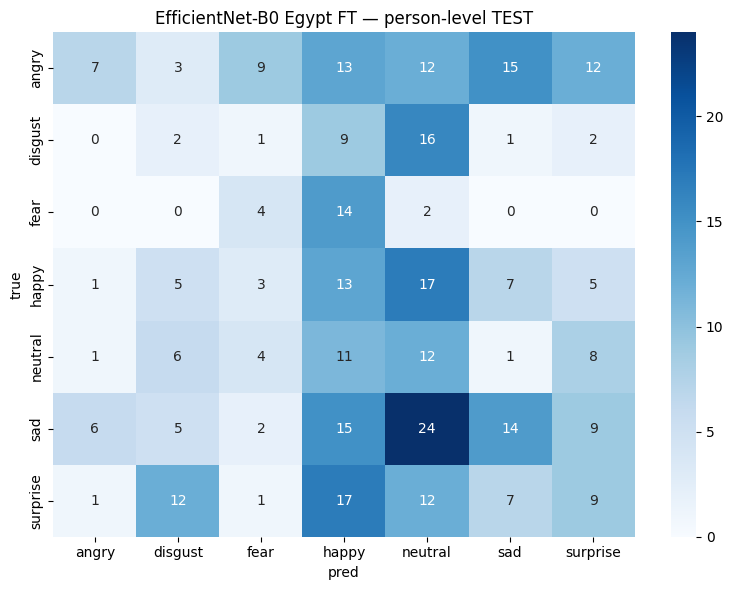

In [25]:
# 9) Person-level TEST evaluation
y_true, y_pred = [], []
for xb, yb in test_ds:
    probs = model.predict(xb, verbose=0)
    y_true.extend(yb.numpy().tolist())
    y_pred.extend(probs.argmax(axis=1).tolist())

y_true = np.array(y_true)
y_pred = np.array(y_pred)
acc = float((y_true == y_pred).mean())
macro_f1 = float(f1_score(y_true, y_pred, average="macro", zero_division=0))

print(f"TEST accuracy: {acc:.4f}")
print(f"TEST macro-F1: {macro_f1:.4f}")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, zero_division=0))

cm = confusion_matrix(y_true, y_pred, labels=list(range(len(CLASS_NAMES))))
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title("EfficientNet-B0 Egypt FT — person-level TEST")
plt.ylabel("true")
plt.xlabel("pred")
plt.tight_layout()
plt.show()


In [26]:
# 10) Save final .h5 + metrics
assert has_efficientnet(model), "Abort save — model is not EfficientNet"

h5_path = OUT_DIR / "best_model_efficientnet_egypt_ft_v4.h5"
model.save(str(h5_path))
print("Saved:", h5_path)

metrics = {
    "backbone": "EfficientNetB0",
    "stage": "egypt_finetune_video_emotion",
    "image_size": IMAGE_SIZE,
    "class_names": CLASS_NAMES,
    "frames_root": str(FRAMES_ROOT),
    "baseline": str(BASELINE_H5),
    "test_accuracy": acc,
    "test_macro_f1": macro_f1,
    "class_weight": CLASS_WEIGHT,
    "n_train": int((df.split == "train").sum()),
    "n_val": int((df.split == "val").sum()),
    "n_test": int((df.split == "test").sum()),
    "n_persons_train": int(df.loc[df.split == "train", PERSON_COL].nunique()),
    "n_persons_val": int(df.loc[df.split == "val", PERSON_COL].nunique()),
    "n_persons_test": int(df.loc[df.split == "test", PERSON_COL].nunique()),
}
(OUT_DIR / "egypt_ft_metrics.json").write_text(json.dumps(metrics, indent=2))
print(json.dumps(metrics, indent=2))

from google.colab import files
files.download(str(h5_path))
print("Also on Drive:", h5_path)
print("Copy into smartshop/mood_model/artifacts/models/")
print("Then smoke test:")
print("python webcam_test_h5.py --model artifacts/models/best_model_efficientnet_egypt_ft.h5")
print("Later: point mood_api.py DEFAULT_MODEL to that file (when you are ready to update code).")


Saved: /content/drive/MyDrive/MasterData/models/best_model_efficientnet_egypt_ft_v4.h5
{
  "backbone": "EfficientNetB0",
  "stage": "egypt_finetune_video_emotion",
  "image_size": 96,
  "class_names": [
    "angry",
    "disgust",
    "fear",
    "happy",
    "neutral",
    "sad",
    "surprise"
  ],
  "frames_root": "/content/drive/MyDrive/MasterData/egypt_modalink_frames_v3",
  "baseline": "/content/best_model_efficientnet_b0.h5",
  "test_accuracy": 0.1742857142857143,
  "test_macro_f1": 0.16676845767925227,
  "class_weight": {
    "0": 0.3158008658008658,
    "1": 1.4887755102040816,
    "2": 2.06138147566719,
    "3": 1.9049923195084486,
    "4": 3.500327153762268,
    "5": 0.759579341940858,
    "6": 1.7586160714285715
  },
  "n_train": 1459,
  "n_val": 326,
  "n_test": 350,
  "n_persons_train": 139,
  "n_persons_val": 29,
  "n_persons_test": 31
}


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Also on Drive: /content/drive/MyDrive/MasterData/models/best_model_efficientnet_egypt_ft_v4.h5
Copy into smartshop/mood_model/artifacts/models/
Then smoke test:
python webcam_test_h5.py --model artifacts/models/best_model_efficientnet_egypt_ft.h5
Later: point mood_api.py DEFAULT_MODEL to that file (when you are ready to update code).


## After Colab finishes
1. Confirm `egypt_ft_metrics.json` says `"backbone": "EfficientNetB0"`.
2. Copy `best_model_efficientnet_egypt_ft.h5` into `smartshop/mood_model/artifacts/models/`.
3. Local check:
```python
import tensorflow as tf
m = tf.keras.models.load_model("artifacts/models/best_model_efficientnet_egypt_ft.h5", compile=False)
print(any("efficient" in l.name.lower() for l in m.layers))  # must be True
```
4. Keep your validation / correction UI from the other repo.
5. Tell me when to update `mood_api.py` + smoke test to use the new filename.
